In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

In [1]:
import torch

In [2]:
def load_jsonl_as_list(path):
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line))
    return data

def get_iter(logs):
    return [row["iter"] for row in logs]

def get_loss(logs):
    return np.array([row["loss"] for row in logs])
    

In [6]:
logs = {
    "baseline": load_jsonl_as_list("logs/loss_fsdp_baseline.jsonl"),
    "int8": load_jsonl_as_list("logs/loss_fsdp_int8.jsonl"),
    "int8_comp": load_jsonl_as_list("logs/loss_fsdp_int8_comm.jsonl"),
    "topk": load_jsonl_as_list("logs/loss_fsdp_topk099.jsonl"),
    "topk_comp": load_jsonl_as_list("logs/loss_fsdp_topk099_comm.jsonl"),
}

min_len = len(logs[list(logs.keys())[0]])
for log_name in logs:
    min_len = min(min_len, len(logs[log_name]))
    
print(min_len)
for key in logs:
    logs[key] = logs[key][:min_len]

for key in logs:
    print(len(logs[key]))

64
64
64
64
64
64


## Loss

baseline 1.112365622073412
int8 2.3856905847787857
int8_comp 1.8083338662981987
topk 4.137304648756981
topk_comp 3.9672569781541824


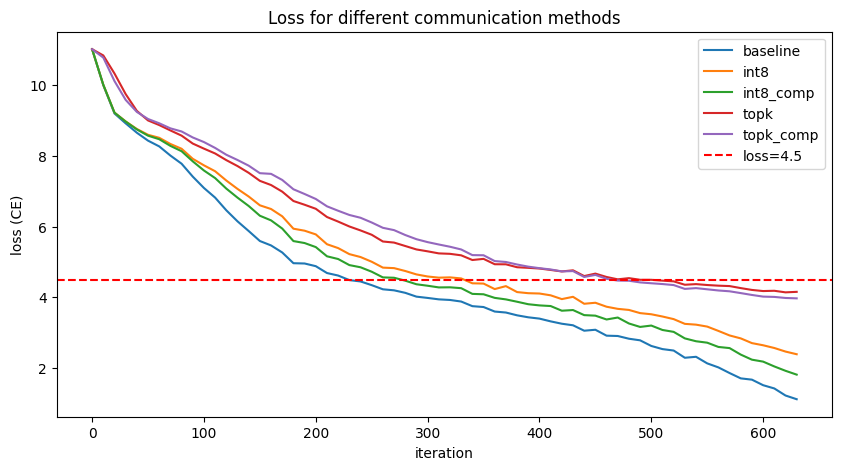

In [9]:
fig, ax = plt.subplots(1, figsize=(10, 5))

for log_name in logs:
    x = get_iter(logs[log_name])
    y = get_loss(logs[log_name])
    print(log_name, min(y))
    ax.plot(x, y, label=log_name)
ax.axhline(y=4.5, color='r', linestyle='--', label="loss=4.5")
ax.set_xlabel("iteration")
ax.set_ylabel("loss (CE)")
ax.legend()
ax.set_title("Loss for different communication methods")
plt.show()

In [52]:
for log_name in logs:
    mean = np.mean(np.diff([row["elapsed_sec"] for row in logs[log_name]]))
    print(log_name, mean)

baseline 55.085903114742706
int8 54.718922100369895
int8_comm 55.938296526197405
topk 55.227279731205535
topk_comm 56.178448143459505


### delta T

In [92]:
def T(logs, L):
    return min(np.where(np.array(logs) <= L)[0])

L = 4.5
t_baseline = T(get_loss(logs["baseline"]), L)
t_int8 = T(get_loss(logs["int8"]), L)
t_int8_comm = T(get_loss(logs["int8_comm"]), L)
t_topk = T(get_loss(logs["topk"]), L)
t_topk_comm = T(get_loss(logs["topk_comm"]), L)

print((t_int8 - t_int8_comm) / t_int8)
print((t_topk - t_topk_comm) / t_topk)

0.17647058823529413
0.04081632653061224


### Gap baseline

In [95]:
print(np.mean(get_loss(logs["int8"]) - get_loss(logs["baseline"])))
print(np.mean(get_loss(logs["int8_comm"]) - get_loss(logs["baseline"])))
print(np.mean(get_loss(logs["topk"]) - get_loss(logs["baseline"])))
print(np.mean(get_loss(logs["topk_comm"]) - get_loss(logs["baseline"])))

0.732843603240326
0.4424561931518838
1.5555782751180232
1.6306001560296863


In [14]:
print(np.min(get_loss(logs["int8"]) - np.min(get_loss(logs["baseline"]))))
print(np.min(get_loss(logs["int8_comp"])) - np.min(get_loss(logs["baseline"])))
print(np.min(get_loss(logs["topk"]) - get_loss(logs["baseline"])))
print(np.min(get_loss(logs["topk_comp"]) - get_loss(logs["baseline"])))

1.2733249627053738
0.6959682442247868
-2.1457672119140625e-06
-2.1457672119140625e-06


### Degradation

In [17]:
deg_int8 = (min(get_loss(logs["int8"])) - min(get_loss(logs["baseline"])))/min(get_loss(logs["baseline"]))
deg_int8_comm = (min(get_loss(logs["int8_comp"])) - min(get_loss(logs["baseline"])))/min(get_loss(logs["baseline"]))
deg_topk = (min(get_loss(logs["topk"])) - min(get_loss(logs["baseline"])))/min(get_loss(logs["baseline"]))
deg_topk_comm = (min(get_loss(logs["topk_comp"])) - min(get_loss(logs["baseline"])))/min(get_loss(logs["baseline"]))

recovery_int8 = (deg_int8_comm - deg_int8) / deg_int8_comm
recovery_topk = (deg_topk_comm - deg_topk) / deg_topk_comm

print(recovery_int8)
print(recovery_topk)

-0.8295733652670939
-0.05956362235662863


In [22]:
recovery_int8 = (min(get_loss(logs["int8"])) - min(get_loss(logs["int8_comp"]))) / (min(get_loss(logs["int8"])) - min(get_loss(logs["baseline"])))
recovery_topk = (min(get_loss(logs["topk"])) - min(get_loss(logs["topk_comp"]))) / (min(get_loss(logs["topk"])) - min(get_loss(logs["baseline"])))

print(recovery_int8)
print(recovery_topk)

0.45342448737822927
0.0562152390850775


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/opt/miniconda3/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
    ~~~~~~~~^^
  File "/opt/miniconda3/lib/python3.13/site-packages/ipykernel/kernelbase.py", line 339, in dispatch_control
    await self.process_control(msg)
  File "/opt/miniconda3/lib/python3.13/site-packages/ipykernel/kernelbase.py", line 345, in process_control
    idents, msg = self.session.feed_identities(msg, copy=False)
                  ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/lib/python3.13/site-packages/jupyter_client/session.py", line 994, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/opt/miniconda3/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.resul

In [19]:
deg_int8, deg_int8_comm

(np.float64(1.1447000315705003), np.float64(0.6256650065538033))

### Message size

In [11]:
for log_name in logs:
    if "comm" in logs[log_name][0]:
        summary = logs[log_name][0]["comm"]["summary"]
        summary = summary[list(summary.keys())[0]]

        iter_size = 0
        for msg in summary:
            msg_size_bytes = summary[msg]["msg_size_bytes"]
            count = summary[msg]["count"]

            iter_size += count * msg_size_bytes
        
        print(log_name, iter_size / 1024 / 1024)

baseline 620.3232421875
int8 310.16182708740234
int8_comp 310.16182708740234
topk 24.812545776367188
topk_comp 24.812545776367188


In [104]:
print(sum(get_loss(logs["int8"])) / 325228248)
print(sum(get_loss(logs["int8_comm"])) / 325228248)
print(sum(get_loss(logs["topk"])) / 26017840)
print(sum(get_loss(logs["topk_comm"])) / 26017840)

1.0210140937285127e-06
9.638702436479984e-07
1.4786686515360405e-05
1.4971229136052456e-05


In [ ]:
4 байта
1 байт

In [2]:
import torch
def quantize_int8_symmetric(x: torch.Tensor):
    x = x.contiguous()

    max_abs = x.abs().max()
    scale = max_abs / 127.0

    if scale.item() == 0.0:
        scale = torch.tensor(1.0, device=x.device, dtype=torch.float32)

    q = torch.clamp(torch.round(x / scale), -127, 127).to(torch.int8)

    return q, scale.float()

In [29]:
a = torch.tensor([[0.8123, -0.156], [-0.581, 0.64]]).to(torch.float32)

q, s = quantize_int8_symmetric(a)
print(q)
print(s)

tensor([[127, -24],
        [-91, 100]], dtype=torch.int8)
tensor(0.0064)


In [36]:
0.0064*127.

0.8128000000000001

In [ ]:
print(q.to(torch.float32) * s - a)

tensor([[ 0.0000,  0.0025],
        [-0.0010, -0.0004]])


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/artem/Desktop/Artem/School/ITMO/Diploma/venv/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/artem/Desktop/Artem/School/ITMO/Diploma/venv/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 348, in dispatch_control
    await self.process_control(msg)
  File "/Users/artem/Desktop/Artem/School/ITMO/Diploma/venv/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 354, in process_control
    idents, msg = self.session.feed_identities(msg, copy=False)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/artem/Desktop/Artem/School/ITMO/Diploma/venv/lib/python3.11/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent 

In [35]:
q.float() * s

tensor([[ 0.8123, -0.1535],
        [-0.5820,  0.6396]])

In [21]:
a

tensor([[ 0.8123, -0.1560],
        [-0.5810,  0.6400]])